<a href="https://colab.research.google.com/github/asha-92ddsmlp/Laptop-Price-Prediction/blob/main/EDA_and_data_visualization_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [40]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [4]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/laptops (1).csv')
df.head()

,Unnamed: 0,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,0,Acer,4,2,1,5,14.0,0.551724,8,256,3.52800,978,Low,0,1
1,1,Dell,3,1,1,3,15.6,0.689655,4,256,4.85100,634,Low,1,0
2,2,Dell,3,1,1,7,15.6,0.931034,8,256,4.85100,946,Low,1,0
3,3,Dell,4,2,1,5,13.3,0.551724,8,128,2.69010,1244,Low,0,1
4,4,HP,4,2,1,7,15.6,0.620690,8,256,4.21155,837,Low,1,0


Q1:

In [5]:
df.shape

(238, 15)

Q2:

In [6]:
df.dtypes

,0
Unnamed: 0,int64
Manufacturer,object
Category,int64
GPU,int64
OS,int64
CPU_core,int64
Screen_Size_inch,float64
CPU_frequency,float64
RAM_GB,int64
Storage_GB_SSD,int64


Q3:

In [7]:
df.isnull().sum()

,0
Unnamed: 0,0
Manufacturer,0
Category,0
GPU,0
OS,0
CPU_core,0
Screen_Size_inch,0
CPU_frequency,0
RAM_GB,0
Storage_GB_SSD,0


Q4:

In [8]:
(df.isnull().sum()/len(df))*100

,0
Unnamed: 0,0.0
Manufacturer,0.0
Category,0.0
GPU,0.0
OS,0.0
CPU_core,0.0
Screen_Size_inch,0.0
CPU_frequency,0.0
RAM_GB,0.0
Storage_GB_SSD,0.0


The percentage of missing values is 0% for all columns. This improves the reliability of the analysis.

Q5:

In [9]:
df.isnull().sum()

,0
Unnamed: 0,0
Manufacturer,0
Category,0
GPU,0
OS,0
CPU_core,0
Screen_Size_inch,0
CPU_frequency,0
RAM_GB,0
Storage_GB_SSD,0


Since no missing values exist, no imputation or deletion techniques are required.

Q6:

In [10]:
df.duplicated().sum()

np.int64(0)

Q7:

In [11]:
df.index.is_unique

True

Q8:

In [12]:
df['Category'].value_counts()

,count
Category,
3,154
4,60
1,14
5,9
2,1


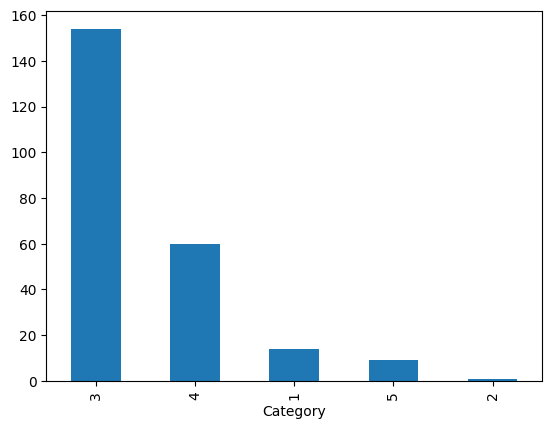

In [13]:
df['Category'].value_counts().plot(kind='bar')
plt.show()

Q9:

In [14]:
df['Manufacturer'].value_counts().head(10)

,count
Manufacturer,
Dell,71
Lenovo,52
HP,49
Acer,19
Asus,18
Toshiba,17
Samsung,5
MSI,4
Huawei,1


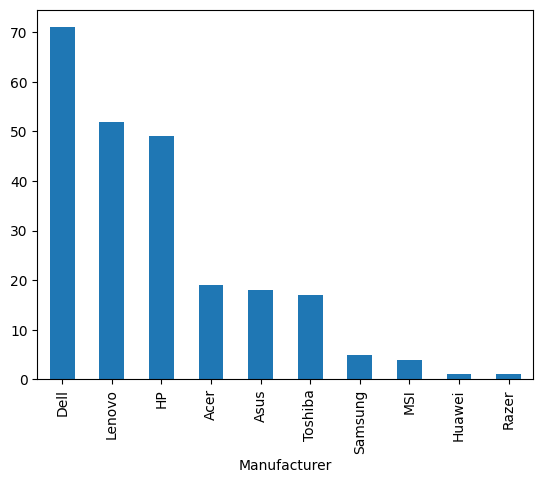

In [15]:
df['Manufacturer'].value_counts().head(10).plot(kind='bar')
plt.show()

Q10:

In [16]:
print(df['Price'].min())
print(df['Price'].max())

527
3810


The cheapest laptop costs 527, while the most expensive laptop costs 3810. This shows a wide variation in laptop pricing.

Q11:

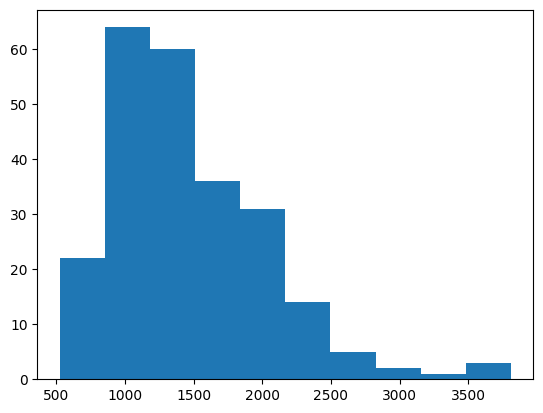

In [17]:
plt.hist(df['Price'])
plt.show()

The price distribution is right-skewed. Most laptops fall within the low to medium price range, while only a few premium laptops have very high prices.

Q12:

In [18]:
df['RAM_GB'].value_counts()

,count
RAM_GB,
8,184
4,33
16,14
6,6
12,1


8 GB RAM is the most common configuration, indicating that it is the standard memory size for most laptops in the dataset.

Q13:

In [19]:
df['CPU_core'].value_counts()

,count
CPU_core,
5,123
7,95
3,20


Most laptops use mid-to-high performance processors, suggesting that manufacturers focus on productivity and multitasking performance.

Q14:

In [20]:
df['GPU'].value_counts()

,count
GPU,
2,136
3,69
1,33


One GPU category clearly dominates the dataset, indicating that most laptops are designed for general-purpose use rather than high-end gaming.

Q15:

In [21]:
df['OS'].value_counts()

,count
OS,
1,224
2,14


The majority of laptops use the same operating system category, indicating its popularity and dominance in the market.

Q16:

In [22]:
df.groupby('Category')['Price'].mean()

,Price
Category,
1,1659.000000
2,2120.000000
3,1274.461039
4,1705.883333
5,2674.666667


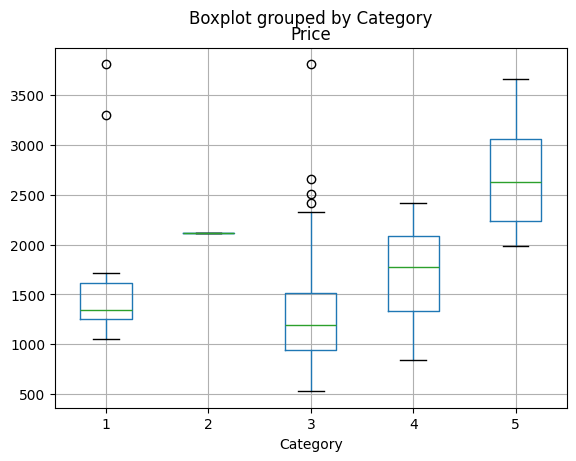

In [23]:
df.boxplot(column='Price', by='Category')
plt.show()

Q17:

In [24]:
df.groupby('OS')['Price'].mean()

,Price
OS,
1,1494.129464
2,953.785714


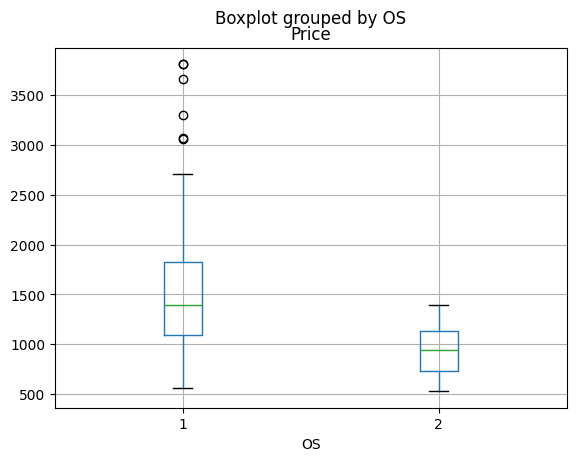

In [25]:
df.boxplot(column='Price', by='OS')
plt.show()

Q18:

In [26]:
pd.crosstab(df['Manufacturer'], df['Category'])

Category,1,2,3,4,5
Manufacturer,,,,,
Acer,2,0,13,4,0
Asus,2,0,10,6,0
Dell,3,0,41,22,5
HP,0,1,35,9,4
Huawei,0,0,0,1,0
Lenovo,2,0,39,11,0
MSI,4,0,0,0,0
Razer,1,0,0,0,0
Samsung,0,0,0,5,0


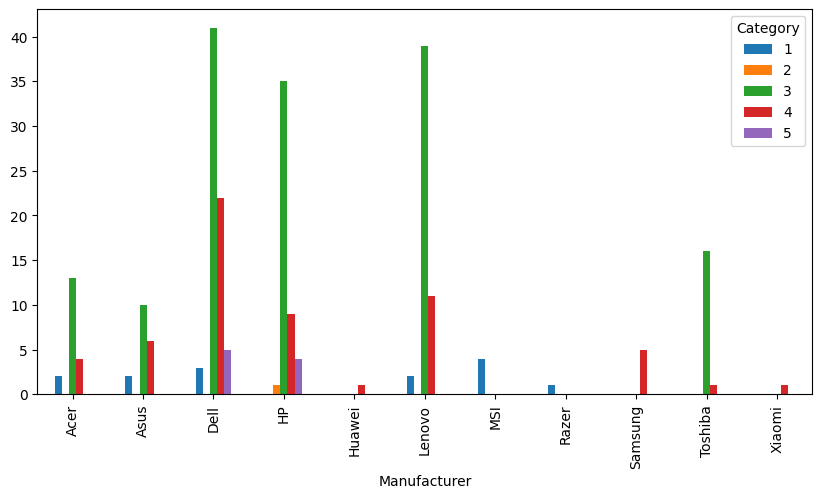

In [27]:
pd.crosstab(df['Manufacturer'], df['Category']).plot(kind='bar', figsize=(10,5))
plt.show()

Q19:

In [28]:
pd.crosstab(df['Manufacturer'], df['Category'])

Category,1,2,3,4,5
Manufacturer,,,,,
Acer,2,0,13,4,0
Asus,2,0,10,6,0
Dell,3,0,41,22,5
HP,0,1,35,9,4
Huawei,0,0,0,1,0
Lenovo,2,0,39,11,0
MSI,4,0,0,0,0
Razer,1,0,0,0,0
Samsung,0,0,0,5,0


Some manufacturers specialize in specific laptop categories, while others offer products across multiple categories to target a wider customer base.

Q20:

In [29]:
print("Average =", df['Storage_GB_SSD'].mean())
print("Minimum =", df['Storage_GB_SSD'].min())
print("Maximum =", df['Storage_GB_SSD'].max())

Average = 245.78151260504202
Minimum = 128
Maximum = 256


Q21:

In [30]:
print("Average RAM =", df['RAM_GB'].mean())

percentage = (df['RAM_GB']==8).mean()*100
print("Percentage of 8GB RAM =", percentage)

Average RAM = 7.882352941176471
Percentage of 8GB RAM = 77.31092436974791


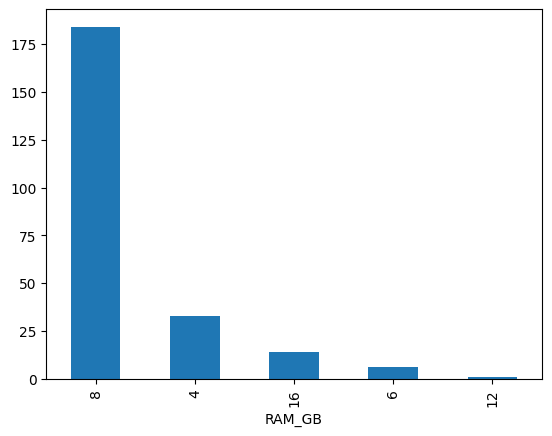

In [31]:
df['RAM_GB'].value_counts().plot(kind='bar')
plt.show()

Q22:

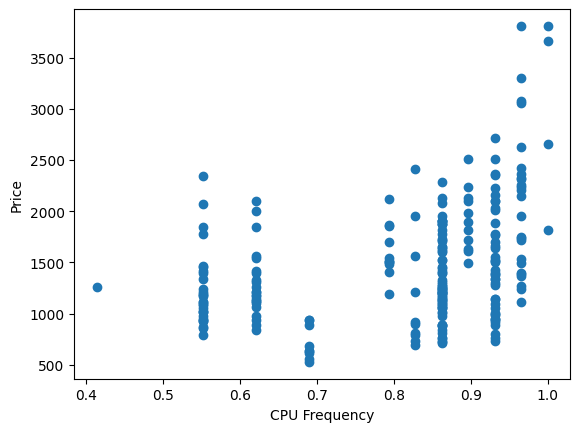

In [32]:
plt.scatter(df['CPU_frequency'], df['Price'])
plt.xlabel("CPU Frequency")
plt.ylabel("Price")
plt.show()

There is a positive relationship between CPU frequency and laptop price. Laptops with faster processors generally cost more.

Q23:

In [33]:
df.groupby('Manufacturer')['RAM_GB'].mean().sort_values(ascending=False)

,RAM_GB
Manufacturer,
Razer,16.000000
Samsung,11.200000
Dell,8.225352
Toshiba,8.000000
Xiaomi,8.000000
Huawei,8.000000
MSI,8.000000
Asus,7.888889
Lenovo,7.576923


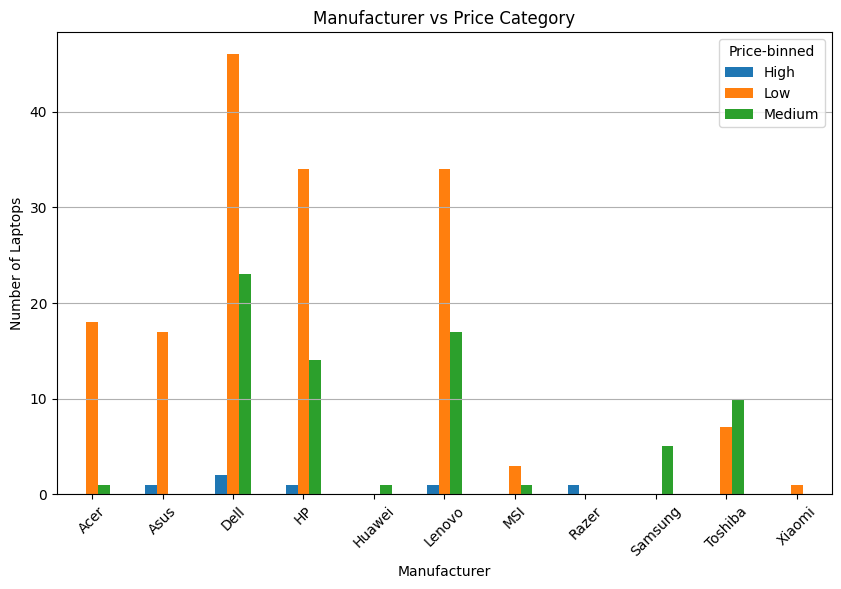

In [35]:
pd.crosstab(
    df["Manufacturer"],
    df["Price-binned"]
).plot(kind="bar", figsize=(10,6))

plt.title("Manufacturer vs Price Category")
plt.xlabel("Manufacturer")
plt.ylabel("Number of Laptops")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

Q24:

In [36]:
print(df.isnull().sum())

Unnamed: 0          0
Manufacturer        0
Category            0
GPU                 0
OS                  0
CPU_core            0
Screen_Size_inch    0
CPU_frequency       0
RAM_GB              0
Storage_GB_SSD      0
Weight_pounds       0
Price               0
Price-binned        0
Screen-Full_HD      0
Screen-IPS_panel    0
dtype: int64


All 15 columns contain 0 missing values.



The dataset is already relatively clean with respect to missing values.

Q25:

Manufacturer
Dell       71
Lenovo     52
HP         49
Acer       19
Asus       18
Toshiba    17
Samsung     5
MSI         4
Huawei      1
Razer       1
Xiaomi      1
Name: count, dtype: int64


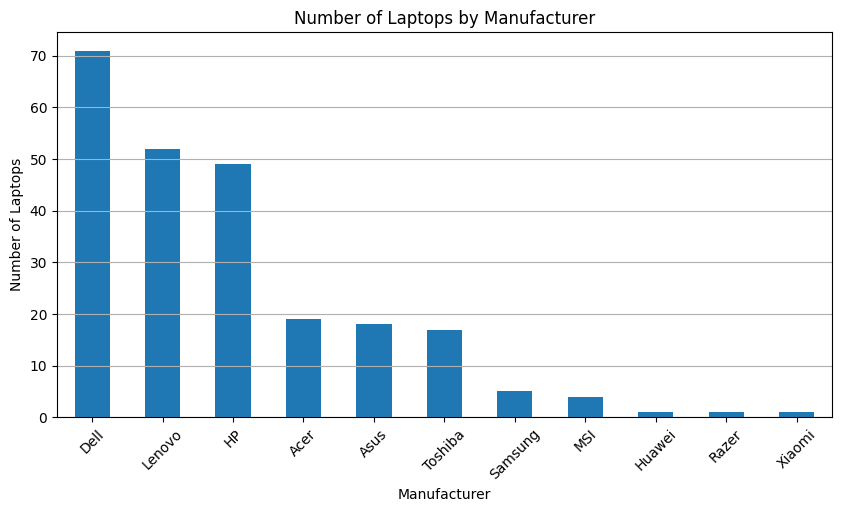

In [37]:
manufacturer_count = df["Manufacturer"].value_counts()

print(manufacturer_count)

manufacturer_count.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Number of Laptops by Manufacturer")
plt.xlabel("Manufacturer")
plt.ylabel("Number of Laptops")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

Q26:

Category
3    154
4     60
1     14
5      9
2      1
Name: count, dtype: int64


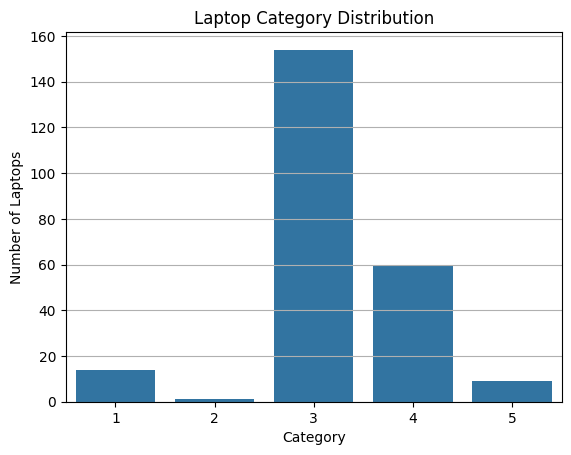

In [41]:


category_count = df["Category"].value_counts()

print(category_count)

sns.countplot(
    data=df,
    x="Category"
)

plt.title("Laptop Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Laptops")
plt.grid(axis="y")
plt.show()

Q27:

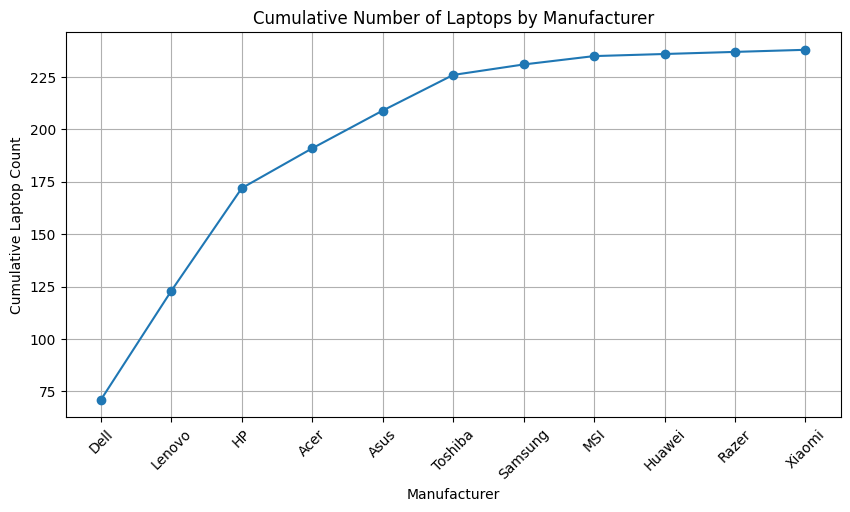

In [42]:
counts = df["Manufacturer"].value_counts()

cumulative = counts.cumsum()

plt.figure(figsize=(10,5))

plt.plot(
    cumulative.index,
    cumulative.values,
    marker="o"
)

plt.title("Cumulative Number of Laptops by Manufacturer")
plt.xlabel("Manufacturer")
plt.ylabel("Cumulative Laptop Count")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

After:

Dell → ~29.8%
Dell + Lenovo → ~51.7%
Dell + Lenovo + HP → ~72.3%


Just the top three manufacturers account for about 72% of the dataset.

This shows a strong concentration around Dell, Lenovo and HP.

Q28:

In [43]:
price_range = df.groupby("Manufacturer")["Price"].agg(
    ["min", "max"]
)

price_range["Price_Range"] = (
    price_range["max"] - price_range["min"]
)

print(
    price_range.sort_values(
        "Price_Range",
        ascending=False
    )
)

               min   max  Price_Range
Manufacturer                         
Asus           527  3810         3283
Lenovo         634  3810         3176
Dell           616  3665         3049
HP             558  3073         2515
Toshiba       1198  2509         1311
Acer           727  1650          923
MSI           1268  1714          446
Samsung       1904  2349          445
Huawei        1714  1714            0
Razer         3301  3301            0
Xiaomi        1188  1188            0


Q29:

In [44]:
df["Price_per_GB"] = (
    df["Price"] / df["Storage_GB_SSD"]
)

print(
    df[
        ["Price", "Storage_GB_SSD", "Price_per_GB"]
    ].head()
)

   Price  Storage_GB_SSD  Price_per_GB
0    978             256      3.820312
1    634             256      2.476562
2    946             256      3.695312
3   1244             128      9.718750
4    837             256      3.269531


In [45]:
df["RAM_per_CPU"] = df["RAM_GB"] / df["CPU_core"]

df["Storage_per_RAM"] = (
    df["Storage_GB_SSD"] / df["RAM_GB"]
)

Q30:

In [46]:
pair_count = (
    df.groupby(
        ["Manufacturer", "GPU"]
    ).size()
    .sort_values(ascending=False)
)

print(pair_count.head(10))

Manufacturer  GPU
Lenovo        2      38
Dell          2      31
HP            2      30
Dell          1      25
              3      15
Toshiba       2      15
HP            3      14
Lenovo        3      11
Acer          3      11
Asus          2       9
dtype: int64


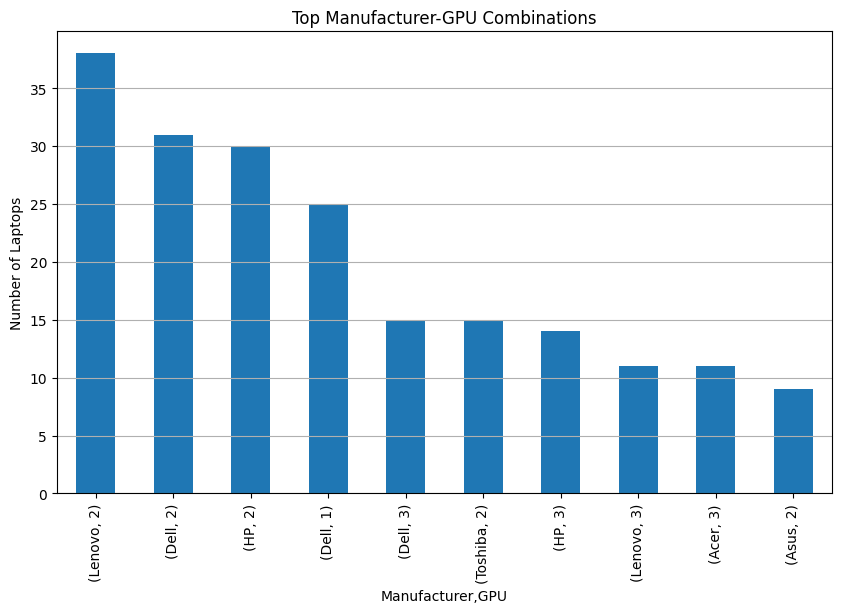

In [47]:
top_pairs = pair_count.head(10)

top_pairs.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Top Manufacturer-GPU Combinations")
plt.ylabel("Number of Laptops")
plt.grid(axis="y")
plt.show()

Q31:

In [48]:
manufacturer_words = (
    df["Manufacturer"]
    .value_counts()
)

print(manufacturer_words.head(10))

Manufacturer
Dell       71
Lenovo     52
HP         49
Acer       19
Asus       18
Toshiba    17
Samsung     5
MSI         4
Huawei      1
Razer       1
Name: count, dtype: int64


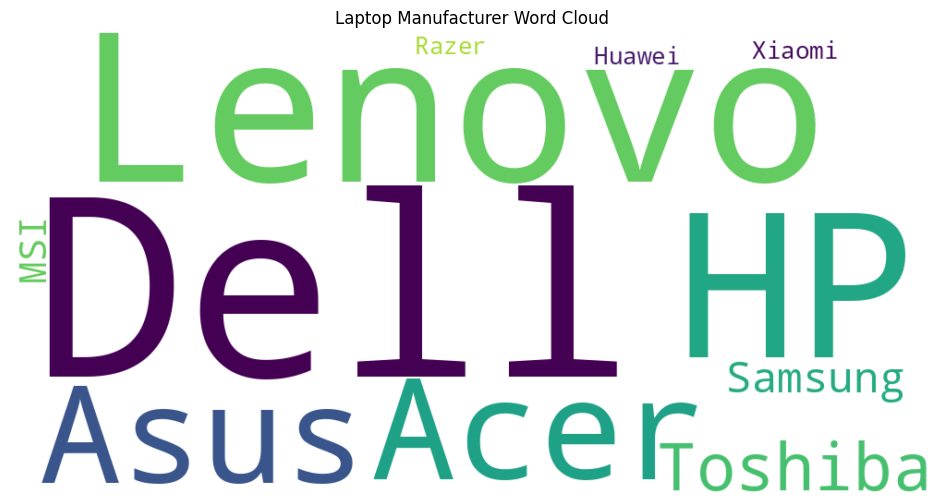

In [49]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(
    df["Manufacturer"].astype(str)
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Laptop Manufacturer Word Cloud")
plt.show()

Q32:

In [52]:
'price-binned' == "High"

False

In [53]:
premium = df[df["Price-binned"] == "High"]

percentage = (
    len(premium) / len(df)
) * 100

print("Premium laptops:", len(premium))
print("Percentage:", percentage)

print(
    premium["Manufacturer"].value_counts()
)

Premium laptops: 6
Percentage: 2.5210084033613445
Manufacturer
Dell      2
Asus      1
Lenovo    1
Razer     1
HP        1
Name: count, dtype: int64


Q33:

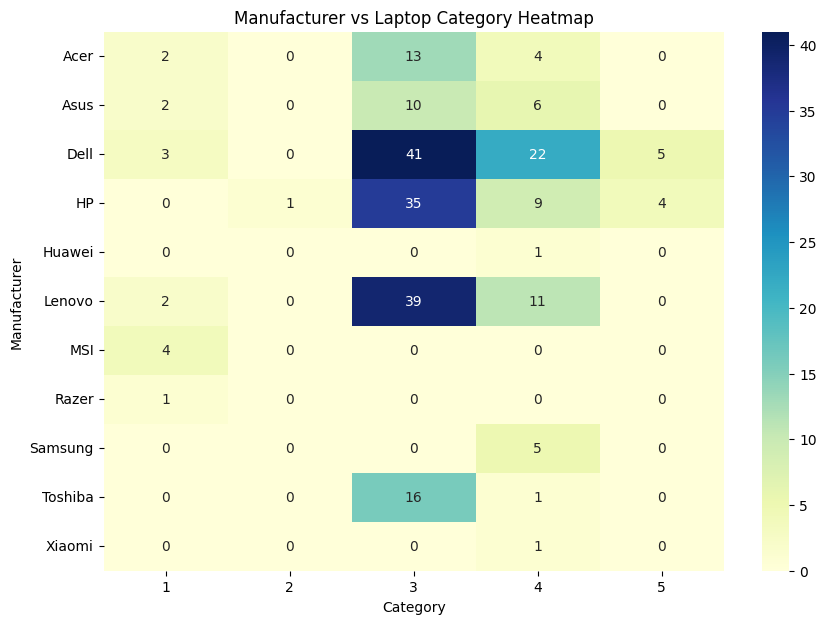

In [54]:
heatmap_data = pd.crosstab(
    df["Manufacturer"],
    df["Category"]
)

plt.figure(figsize=(10,7))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="d",
    cmap="YlGnBu"
)

plt.title(
    "Manufacturer vs Laptop Category Heatmap"
)

plt.xlabel("Category")
plt.ylabel("Manufacturer")

plt.show()

Q34:

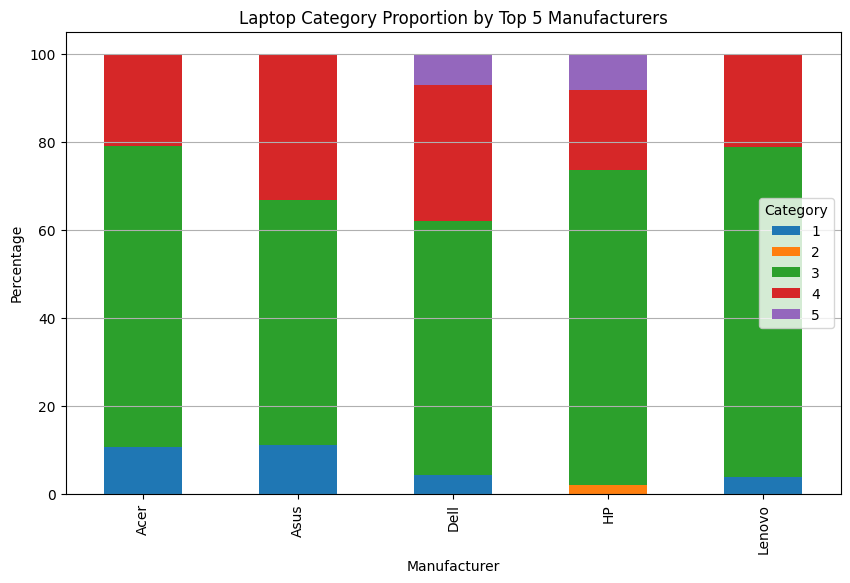

In [55]:
top5 = (
    df["Manufacturer"]
    .value_counts()
    .head(5)
    .index
)

data = df[
    df["Manufacturer"].isin(top5)
]

table = pd.crosstab(
    data["Manufacturer"],
    data["Category"],
    normalize="index"
) * 100

table.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title(
    "Laptop Category Proportion by Top 5 Manufacturers"
)

plt.ylabel("Percentage")
plt.xlabel("Manufacturer")

plt.legend(title="Category")
plt.grid(axis="y")

plt.show()

Q35:

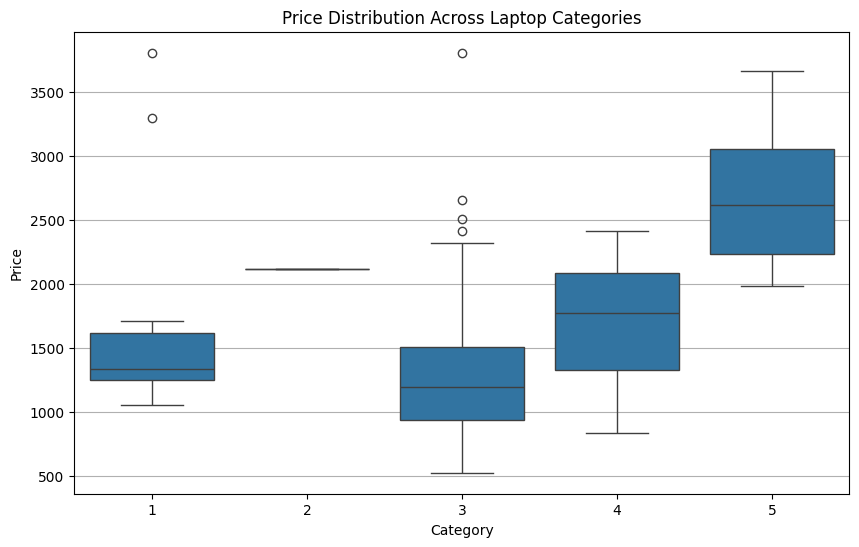

In [56]:
top_categories = (
    df["Category"]
    .value_counts()
    .head(5)
    .index
)

data = df[
    df["Category"].isin(top_categories)
]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=data,
    x="Category",
    y="Price"
)

plt.title(
    "Price Distribution Across Laptop Categories"
)

plt.xlabel("Category")
plt.ylabel("Price")

plt.grid(axis="y")

plt.show()

Q36:

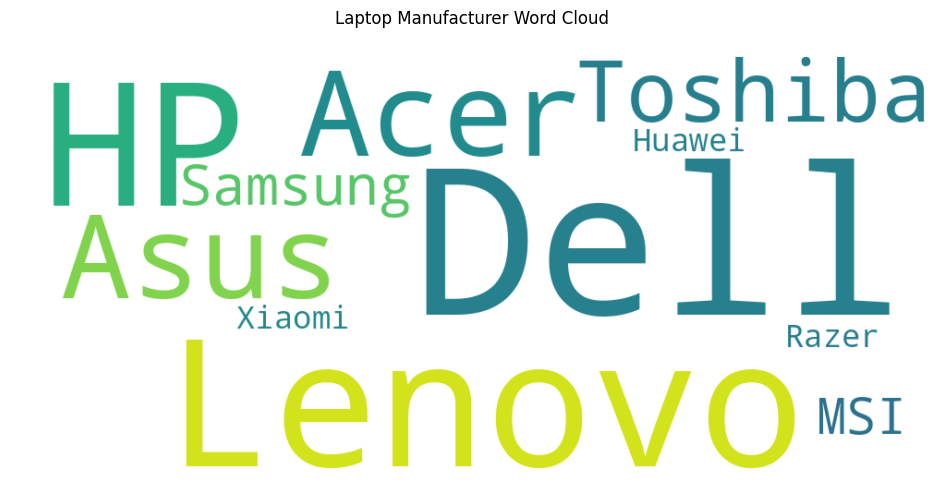

In [57]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(
    df["Manufacturer"].astype(str)
)

wc = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))

plt.imshow(
    wc,
    interpolation="bilinear"
)

plt.axis("off")
plt.title("Laptop Manufacturer Word Cloud")

plt.show()

Q37:

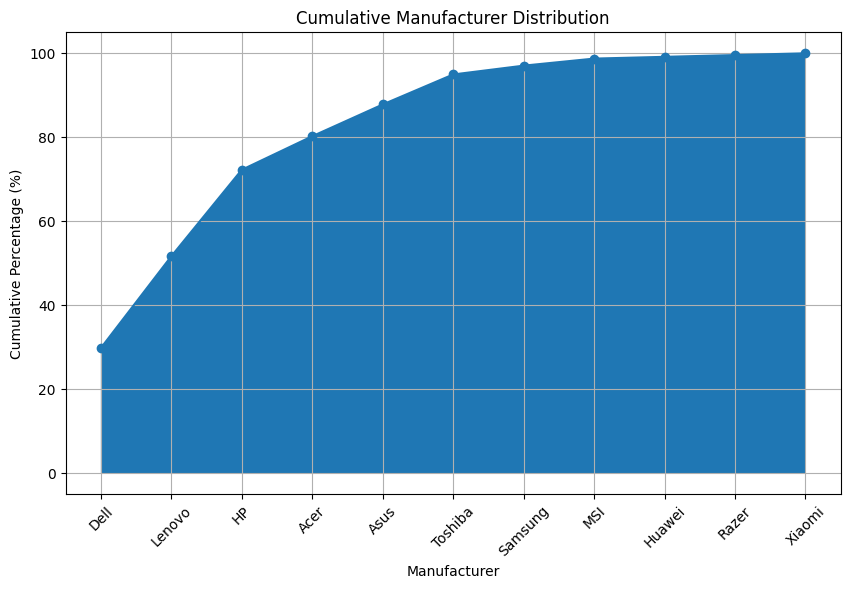

In [58]:
counts = df["Manufacturer"].value_counts()

cumulative_percentage = (
    counts.cumsum() / len(df) * 100
)

plt.figure(figsize=(10,6))

plt.fill_between(
    range(len(cumulative_percentage)),
    cumulative_percentage
)

plt.plot(
    range(len(cumulative_percentage)),
    cumulative_percentage,
    marker="o"
)

plt.xticks(
    range(len(cumulative_percentage)),
    cumulative_percentage.index,
    rotation=45
)

plt.ylabel("Cumulative Percentage (%)")
plt.xlabel("Manufacturer")

plt.title(
    "Cumulative Manufacturer Distribution"
)

plt.grid(True)

plt.show()

Q38:

In [59]:
import plotly.express as px

price_counts = (
    df["Price-binned"]
    .value_counts()
    .reset_index()
)

price_counts.columns = [
    "Price_Category",
    "Count"
]

fig = px.treemap(
    price_counts,
    path=["Price_Category"],
    values="Count",
    title="Laptop Price Category Distribution"
)

fig.show()

Q39:

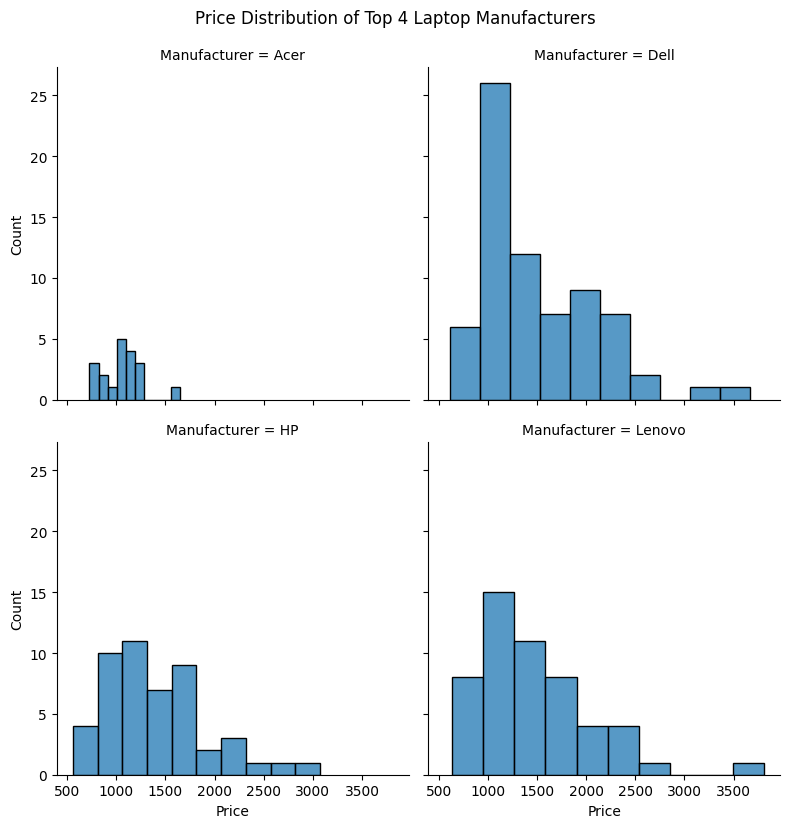

In [60]:
top4 = (
    df["Manufacturer"]
    .value_counts()
    .head(4)
    .index
)

data = df[
    df["Manufacturer"].isin(top4)
]

g = sns.FacetGrid(
    data,
    col="Manufacturer",
    col_wrap=2,
    height=4
)

g.map(
    sns.histplot,
    "Price",
    bins=10
)

g.fig.suptitle(
    "Price Distribution of Top 4 Laptop Manufacturers",
    y=1.03
)

plt.show()

Q40

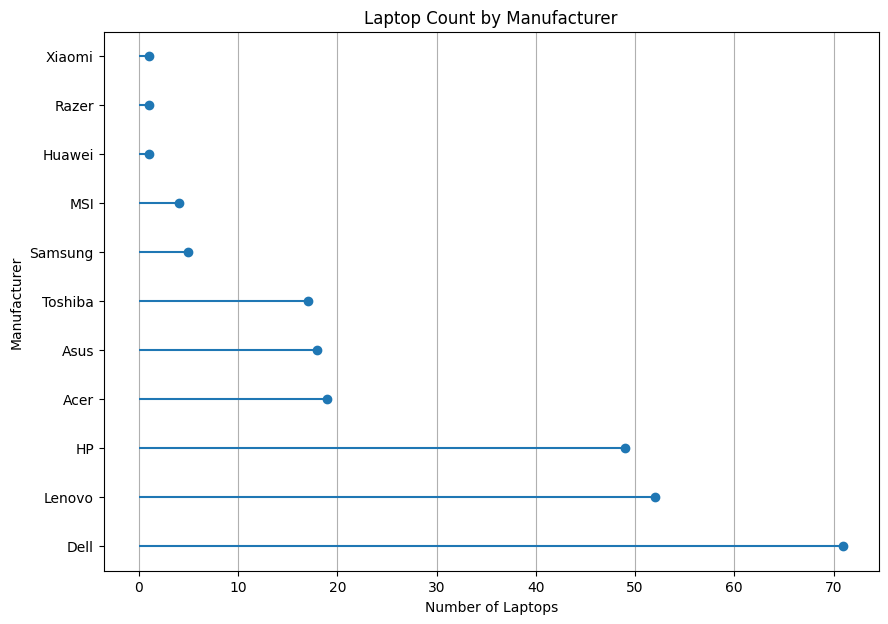

In [61]:
counts = df["Manufacturer"].value_counts()

plt.figure(figsize=(10,7))

plt.hlines(
    y=counts.index,
    xmin=0,
    xmax=counts.values
)

plt.plot(
    counts.values,
    counts.index,
    "o"
)

plt.title(
    "Laptop Count by Manufacturer"
)

plt.xlabel("Number of Laptops")
plt.ylabel("Manufacturer")

plt.grid(axis="x")

plt.show()

Q41:

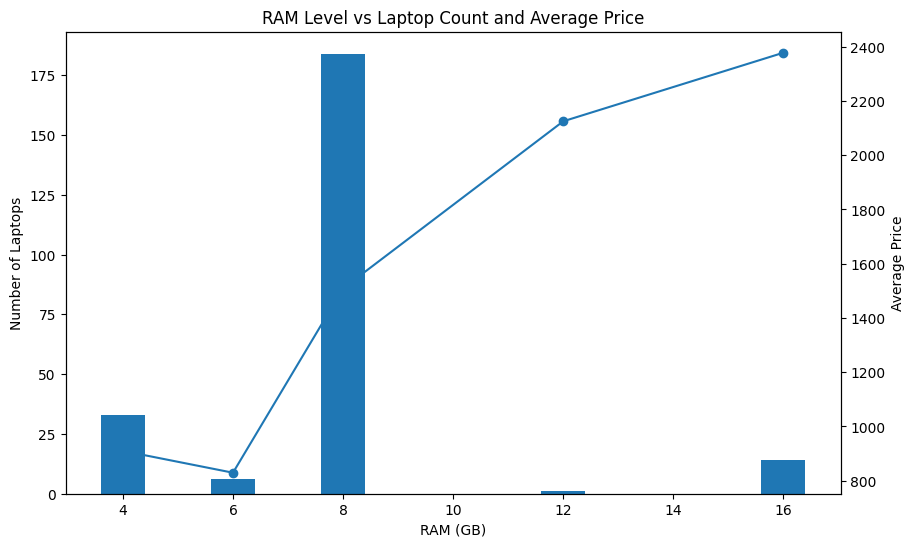

In [62]:
ram_analysis = (
    df.groupby("RAM_GB")
    .agg(
        Laptop_Count=("Price", "count"),
        Average_Price=("Price", "mean")
    )
    .sort_index()
)

fig, ax1 = plt.subplots(figsize=(10,6))

# Bar chart
ax1.bar(
    ram_analysis.index,
    ram_analysis["Laptop_Count"]
)

ax1.set_xlabel("RAM (GB)")
ax1.set_ylabel("Number of Laptops")

# Second axis
ax2 = ax1.twinx()

ax2.plot(
    ram_analysis.index,
    ram_analysis["Average_Price"],
    marker="o"
)

ax2.set_ylabel("Average Price")

plt.title(
    "RAM Level vs Laptop Count and Average Price"
)

plt.show()

Q42:

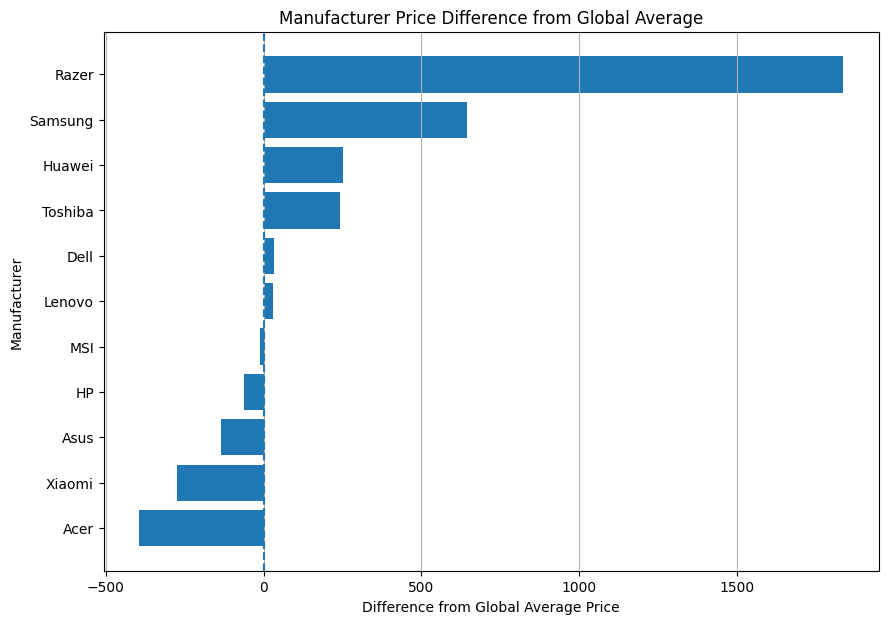

In [63]:
global_average = df["Price"].mean()

manufacturer_avg = (
    df.groupby("Manufacturer")["Price"]
    .mean()
)

difference = (
    manufacturer_avg - global_average
)

difference = difference.sort_values()

plt.figure(figsize=(10,7))

plt.barh(
    difference.index,
    difference.values
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title(
    "Manufacturer Price Difference from Global Average"
)

plt.xlabel(
    "Difference from Global Average Price"
)

plt.ylabel("Manufacturer")

plt.grid(axis="x")

plt.show()




Final Conclusion:

The analysis of the Laptop dataset provided useful insights into laptop specifications, manufacturers, categories, and prices. The dataset contains 238 laptop records, and the exploratory data analysis showed that laptop prices vary considerably, ranging from approximately $527 to $3810, with an average price of around $1462.

The analysis found that Dell is the most frequently represented manufacturer, followed by Lenovo and HP. Together, these three manufacturers account for a large portion of the dataset. 8 GB RAM is the most common configuration, representing approximately 77% of the laptops. The majority of laptops also fall into the Low-price category, while only a small percentage belong to the High-price category.

The visualization and correlation analysis also revealed that RAM, CPU specifications, storage, and GPU are important factors related to laptop price. In particular, laptops with higher RAM generally tend to have higher prices. CPU frequency also shows a positive relationship with price, although the relationship is not strong enough to predict price by itself.

Advanced visualizations such as heatmaps, box plots, stacked bar charts, treemaps, lollipop charts, facet grids, and dual-axis charts helped identify patterns and differences between manufacturers, categories, specifications, and prices.
From a Data Science and Machine Learning perspective, these findings indicate that laptop price can be treated as a suitable target variable for a regression problem. Features such as RAM, CPU core, CPU frequency, GPU, storage, screen size, weight, and manufacturer can be used to build predictive models.
Therefore, the next step of this project would be to perform feature preprocessing and feature selection, followed by training different machine-learning regression models such as Linear Regression, Decision Tree Regression, and Random Forest Regression. Their performance can then be compared using MAE, MSE/RMSE, and R² score to select the best model for laptop price prediction.

Overall Conclusion:

The analysis shows that laptop prices are influenced by multiple hardware and product characteristics rather than a single feature. RAM, CPU, GPU, storage, manufacturer, and other specifications play important roles in determining price. Therefore, machine-learning techniques can be effectively applied to this dataset to develop a model capable of predicting laptop prices based on their specifications.
Short version for presentation
“In conclusion, our exploratory data analysis identified important relationships between laptop specifications and price. Dell, Lenovo, and HP dominate the dataset, while 8 GB RAM is the most common configuration. Higher RAM and better hardware specifications generally correspond to higher prices. These findings provide a strong foundation for building a machine-learning regression model to predict laptop prices.”